# Solving the Head and Neck Tumor Segmentation for MR-Guided Applications(HNTS-MRG) with UNETR

### Installing and setting up correct dependencies for the environment

In [11]:
%pip install -q "monai-weekly[nibabel, tqdm, einops]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [12]:
import os
from glob import glob
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime

from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.networks.nets import UNETR
from monai.transforms import (
    AsDiscrete,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandFlipd,
    RandCropByPosNegLabeld,
    RandShiftIntensityd,
    ScaleIntensityRanged,
    Spacingd,
    RandRotate90d,
)
from monai.data import (
    DataLoader,
    Dataset,
    CacheDataset,
    decollate_batch,
)

# from monai.config import print_config
# print_config()

### Setting up directories for training

Project is set up to access dataset stored at the Cybele lab at NTNU.

In [13]:
directory = "data_directory"
os.makedirs(directory, exist_ok=True)
root_dir = directory

# Define the correct training directory path
base_directory = "/datasets/tdt4265/mic/open/HNTS-MRG"

print(f"Base directory path: {base_directory}")
print(f"Base directory exists: {os.path.exists(base_directory)}")

Base directory path: /datasets/tdt4265/mic/open/HNTS-MRG
Base directory exists: True


### Hyperparameters

In [14]:
# Training parameters
max_epochs = 10
batch_size = 1

# Data processing parameters
train_validation_split = 0.8
model_save_rate = 2 # How often the model is saved

# Preprocessing parameters
crop_pos = 1
crop_neg = 1

# UNETR model parameters
patch_size=(64, 64, 32)
feature_size=16
hidden_size=768
mlp_dim=3072
num_heads=12
proj_type="perceptron"
norm_name="instance"
res_block=True
dropout_rate=0.0

# Optimizer parameters
lr=1e-4
weight_decay=1e-5

In [15]:
# Sort patients into a list in accending order
train_patients = sorted(glob(os.path.join(base_directory, "train", "[0-9]*")), key=lambda x: int(os.path.basename(x)))
test_patients = sorted(glob(os.path.join(base_directory, "test", "[0-9]*")), key=lambda x: int(os.path.basename(x)))

# Organize patients into dictionaries with image and corresponding label for each patient
train_files = []
for patient in train_patients:
    train_files.append({"image": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_T2.nii.gz")), "label": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_mask.nii.gz"))})
test_files = []
for patient in test_patients:
    test_files.append({"image": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_T2.nii.gz")), "label": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_mask.nii.gz"))})

# Split training into train and validation data
train_files, val_files = train_test_split(train_files, train_size=train_validation_split)

### Inspect images

Inspecting images to determine intensity values of the T2-weighted scans as these are not standardized in MR-scans.

In [16]:
train_samples = glob(os.path.join(base_directory, "train", "[0-9]*", "preRT", "[0-9]*_preRT_T2.nii.gz"))
test_samples = glob(os.path.join(base_directory, "test", "[0-9]*", "preRT", "[0-9]*_preRT_T2.nii.gz"))

min_intensities = []
max_intensities = []
mean_intensities = []
std_intensities = []
p1_intensities = []
p99_intensities = []
scan_dimensions = []

# for sample in train_samples:
#     img = nib.load(sample)
#     data = img.get_fdata()

#     min_intensities.append(data.min())
#     max_intensities.append(data.max())
#     mean_intensities.append(data.mean())
#     std_intensities.append(data.std())
#     p1_intensities.append(np.percentile(data, 1))
#     p99_intensities.append(np.percentile(data, 99))

#     scan_dimensions.append(data.shape)

# for sample in test_samples:
#     img = nib.load(sample)
#     data = img.get_fdata()

#     scan_dimensions.append(data.shape)

# print(max(p99_intensities))
# print(min(p1_intensities))
# print(scan_dimensions)

Using 1st and 99th percentiles to accurately capture intensities while also eliminating outliers from faulty scans.

### Transforms

Defining transformations for train, validation and test datasets.
The random transformations are only applied to the training data.

In [17]:
# Initial transforms for training, validation and testing datasets
pre_cache_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys="image", a_min=0.0, a_max=2572.0, b_min=0.0, b_max=1.0, clip=True), #Using values found above
    CropForegroundd(keys=["image", "label"], source_key="image"),
])

# Random data augmentation for train dataset
post_cache_train_transforms = Compose([
    RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=patch_size, pos=crop_pos, neg=crop_neg, num_samples=4, image_key="image", image_threshold=0),
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[1], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[2], prob=0.10),
    RandRotate90d(keys=["image", "label"], prob=0.10, max_k=3),
    RandShiftIntensityd(keys="image", offsets=0.10, prob=0.50)
])

/home/hermaos/.local/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


### Set up cache and dataloader

In [18]:
train_cache = CacheDataset(
    data=train_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18, #24 threads available on Cybele computers
)

val_cache = CacheDataset(
    data=val_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18,
)

test_cache = CacheDataset(
    data=test_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18, #Caching between train, val  and test is done in series, not at the same time
)

# Apply random transformations at access time only to training data
random_train_cache = Dataset(
    data=train_cache,
    transform=post_cache_train_transforms
)

train_loader = DataLoader(
    dataset=random_train_cache,
    batch_size=batch_size,
    shuffle=True,
    num_workers=18,
    pin_memory=True,
    # collate_fn=pad_list_data_collate,
)

val_loader = DataLoader(
    dataset=val_cache,
    batch_size=batch_size,
    shuffle=False,
    num_workers=18,
    pin_memory=True,
    # collate_fn=pad_list_data_collate,
)

test_loader = DataLoader(
    dataset=test_cache,
    batch_size=batch_size,
    shuffle=False,
    num_workers=18,
    pin_memory=True,
    # collate_fn=pad_list_data_collate,
)


Loading dataset:   0%|          | 0/104 [00:00<?, ?it/s]

Loading dataset: 100%|██████████| 20/20 [00:05<00:00,  3.49it/s]


### Checking transformations and dataloader by visualizing an image

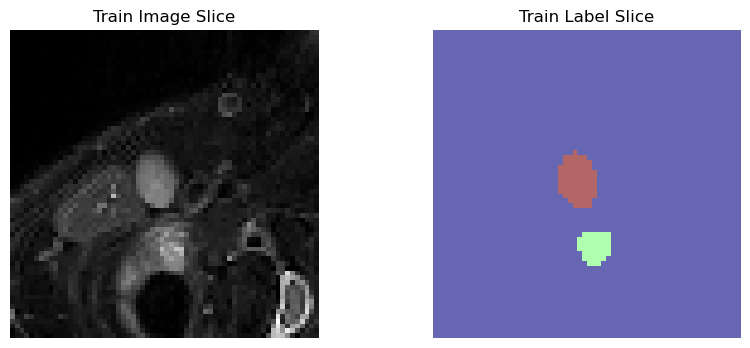

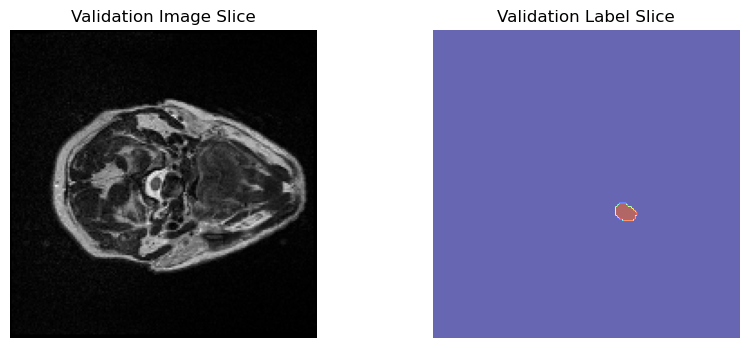

In [29]:
# Get a single scan after transformations
train_scan = next(iter(train_loader))
val_scan = next(iter(val_loader))

# Access image and label in scan
train_image = train_scan["image"]
train_label = train_scan["label"]

val_image = val_scan["image"]
val_label = val_scan["label"]

# [B, C, H, W, D] → [H, W, D]
train_image_np = train_image[0][0].detach().cpu().numpy()
train_label_np = train_label[0][0].detach().cpu().numpy()

val_image_np = val_image[0][0].detach().cpu().numpy()
val_label_np = val_label[0][0].detach().cpu().numpy()

# Pick a central slice
train_slice_id = train_image_np.shape[2] // 2
val_slice_id = val_image_np.shape[2] // 2

train_image_slice = train_image_np[:, :, train_slice_id]
train_label_slice = train_label_np[:, :, train_slice_id]

val_image_slice = val_image_np[:, :, val_slice_id]
val_label_slice = val_label_np[:, :, val_slice_id]

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(train_image_slice, cmap="gray")
plt.title("Train Image Slice")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(train_label_slice, cmap="jet", alpha=0.6)
plt.title("Train Label Slice")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(val_image_slice, cmap="gray")
plt.title("Validation Image Slice")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(val_label_slice, cmap="jet", alpha=0.6)
plt.title("Validation Label Slice")
plt.axis("off")
plt.show()

### Defining model, optimizer and loss function

In [23]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNETR(
    in_channels=1,
    out_channels=3,
    img_size=patch_size,
    feature_size=feature_size,
    hidden_size=hidden_size,
    mlp_dim=mlp_dim,
    num_heads=num_heads,
    proj_type=proj_type,
    norm_name=norm_name,
    res_block=res_block,
    dropout_rate=dropout_rate,
).to(device)

# Using Dice with Cross Entropy Loss for training
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
torch.backends.cudnn.benchmark = True
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# Setup writer for Tensorboard
run_name = f"experiment_bs16_lr1e4_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
writer = SummaryWriter(log_dir=os.path.join(root_dir, "runs", run_name))

architecture = str(model)
optimizer_notes = str(optimizer)
preprocessing_notes = f"CropByNegPosLabeld: pos={crop_pos}, neg={crop_neg}"
postprocessing_notes = "No postprocessing"

experiment_notes = f"""
### Experiment Info

**Model Architecture:**
{architecture}

**Optimizer**
{optimizer}

**Preprocessing:**
- CropByNegPosLabeld:
  - pos: {crop_pos}
  - neg: {crop_neg}
  - class weights: No

**Postprocessing:**
- {postprocessing_notes}

**Hyperparameters**
- Learning rate: {lr}
- Weight decay: {weight_decay}
"""

writer.add_text("Experiment Info", experiment_notes)

### Training and validation methods

In [ ]:
post_label = AsDiscrete(to_onehot=3)
post_pred = AsDiscrete(argmax=True, to_onehot=3)
# Using regular Dice for validation
dice_metric = DiceMetric(include_background=False, reduction="none", get_not_nans=False)

total_batch_step_count = 0
epoch_count = 0

best_batch_step_count = 0
dice_val_best = 0.0

train_loss_values = []
val_loss_values = []

# Validation DICE scores, used as performance metric
combined_dice_scores = []
gtvp_dice_scores = []
gtvn_dice_scores = []

def train(train_loader, total_batch_step_count, best_batch_step_count, epoch_count, best_combined_dice):
    model.train()
    epoch_iterator_train = tqdm(train_loader, dynamic_ncols=True)

    epoch_count += 1
    print(epoch_count)
    epoch_loss = 0

    # Iterates through all batches in 1 epoch (104)
    for step, batch in enumerate(epoch_iterator_train):
        image, label = (batch["image"].cuda(), batch["label"].cuda())
        pred = model(image) # Inference
        loss = loss_function(pred, label)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        total_batch_step_count += 1

    avg_epoch_loss = epoch_loss / len(train_loader)
    train_loss_values.append(avg_epoch_loss)
    writer.add_scalar("Loss/Train", avg_epoch_loss, epoch_count)

    # Running validation after each epoch
    gtvp_dice, gtvn_dice, combined_dice = validate(val_loader)
    gtvp_dice_scores.append(gtvp_dice)
    gtvn_dice_scores.append(gtvn_dice)
    combined_dice_scores.append(combined_dice)
    writer.add_scalar("GTVp Dice", gtvp_dice, epoch_count)
    writer.add_scalar("GTVn Dice", gtvn_dice, epoch_count)
    writer.add_scalar("Combined Dice", combined_dice, epoch_count)
    
    if combined_dice > best_combined_dice:
        best_combined_dice = combined_dice
        best_batch_step_count = total_batch_step_count
        print("Improvement! Current Best Avg. Dice: {} Current Avg. Dice: {}".format(best_combined_dice, combined_dice))
        # Only save some models to save on I/O computation time
        if epoch_count % model_save_rate == 0 or epoch_count == max_epochs:
            torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
            print("Model Was Saved!")
    else:
        print("No improvement. Current Best Avg. Dice: {} Current Avg. Dice: {}".format(best_combined_dice, combined_dice))

    return total_batch_step_count, best_batch_step_count, epoch_count, best_combined_dice

def validate(epoch_iterator_val):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        # Iterates through all batches in 1 epoch (26)
        for step, batch in enumerate(epoch_iterator_val):
            image_val, label_val = (batch["image"].cuda(), batch["label"].cuda())
            outputs_val = sliding_window_inference(image_val, patch_size, 4, model) # Inference

            loss = loss_function(outputs_val, label_val)
            val_loss += loss.item()

            labels_val_list = decollate_batch(label_val)
            outputs_val_list = decollate_batch(outputs_val)
            labels_val_convert = [post_label(val_label_tensor) for val_label_tensor in labels_val_list]
            outputs_val_convert = [post_pred(val_pred_tensor) for val_pred_tensor in outputs_val_list]

            dice_metric(y_pred=outputs_val_convert, y=labels_val_convert)
        
        dice_val = dice_metric.aggregate()
        mean_dice_per_class = torch.nanmean(dice_val, dim=0)

        gtvp_dice = mean_dice_per_class[0].item()
        gtvn_dice = mean_dice_per_class[1].item()
        combined_dice = (gtvp_dice + gtvn_dice) / 2.0
        print(f"Validation GTVp Dice: {gtvp_dice:.4f}, GTVn Dice: {gtvn_dice:.4f}, Combined: {combined_dice:.4f}")

        dice_metric.reset()

        avg_val_loss = val_loss / len(epoch_iterator_val)
        writer.add_scalar("Validation loss", avg_val_loss, epoch_count)
        val_loss_values.append(avg_val_loss)
    return gtvp_dice, gtvn_dice, combined_dice

# Main training loop
for i in range(max_epochs):
    total_batch_step_count, best_batch_step_count, epoch_count, dice_val_best = train(train_loader, total_batch_step_count, best_batch_step_count, epoch_count, dice_val_best)
writer.close()

  0%|          | 0/104 [00:00<?, ?it/s]

1


100%|██████████| 104/104 [00:06<00:00, 15.72it/s]


Validation GTVp Dice: 0.0025, GTVn Dice: 0.0072, Combined: 0.0048
Improvement! Current Best Avg. Dice: 0.004836047766730189 Current Avg. Dice: 0.004836047766730189


  0%|          | 0/104 [00:00<?, ?it/s]

...

Validation GTVp Dice: 0.0000, GTVn Dice: 0.0000, Combined: 0.0000
No improvement. Current Best Avg. Dice: 0.004836047766730189 Current Avg. Dice: 7.621079475939041e-06


  0%|          | 0/104 [00:00<?, ?it/s]

10


100%|██████████| 104/104 [00:06<00:00, 16.03it/s]


Validation GTVp Dice: 0.0000, GTVn Dice: 0.0000, Combined: 0.0000
No improvement. Current Best Avg. Dice: 0.004836047766730189 Current Avg. Dice: 0.0


### Plotting Loss and Dice

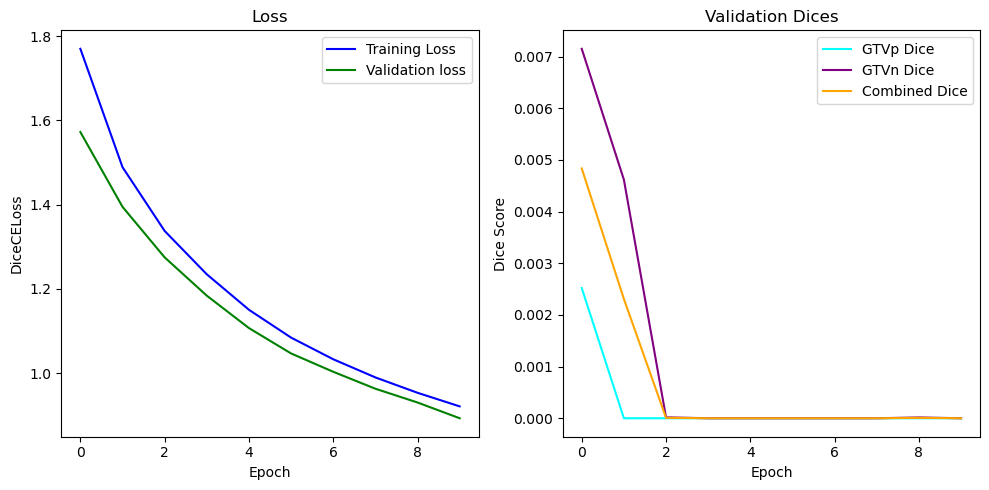

In [25]:
plt.figure(figsize=(10, 5))

# Plotting average training and validation loss for each epoch
plt.subplot(1, 2, 1)
plt.plot(train_loss_values, label="Training Loss", color="blue")
plt.plot(val_loss_values, label="Validation loss", color="green")
plt.xlabel("Epoch")
plt.ylabel("DiceCELoss")
plt.title("Loss")
plt.legend()

# Plotting validation DICE-values for each epoch
plt.subplot(1, 2, 2)
plt.plot(gtvp_dice_scores, label="GTVp Dice", color="cyan")
plt.plot(gtvn_dice_scores, label="GTVn Dice", color="purple")
plt.plot(combined_dice_scores, label="Combined Dice", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Validation Dices")
plt.legend()

plt.tight_layout()
plt.show()

### Testing best model on validation data by visualizing scan, label and prediction

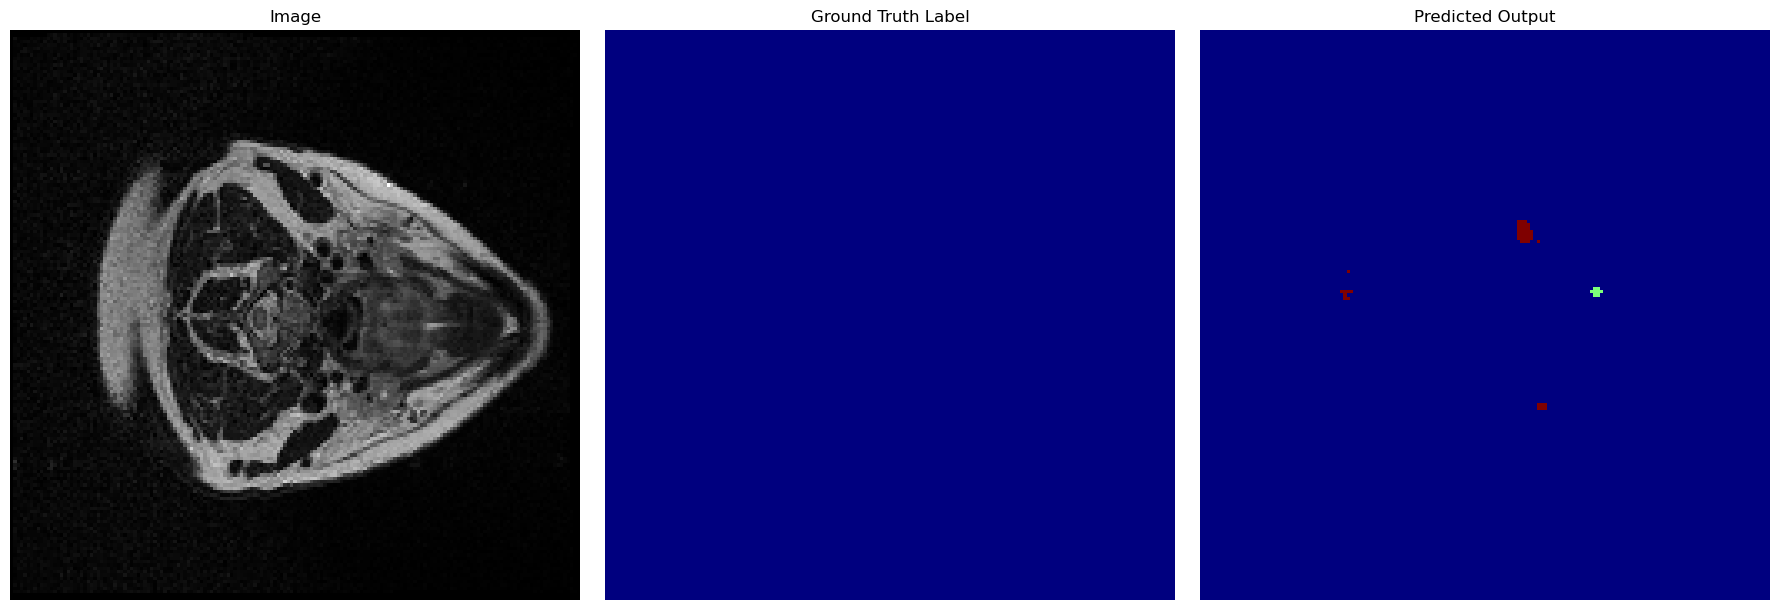

0.3563149869441986


In [26]:
# Choose patient between 1-25
case_num = 10

post_label = AsDiscrete(to_onehot=3)
post_pred = AsDiscrete(argmax=True, to_onehot=3)
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)

# Load best model parameters
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))
model.eval()

for id, batch in enumerate(val_loader):
    if id == case_num:
        val_input, label_input = (batch["image"].cuda(), batch["label"].cuda())
        img_name = os.path.split(batch["image"].meta["filename_or_obj"][0])[1]

        with torch.no_grad():
            val_outputs = sliding_window_inference(val_input, patch_size, 4, model)
        
        # Post-process the outputs and labels
        labels_list = decollate_batch(label_input)
        outputs_list = decollate_batch(val_outputs)
        labels_convert = [post_label(label_tensor) for label_tensor in labels_list]
        outputs_convert = [post_pred(output_tensor) for output_tensor in outputs_list]

        # Convert to numpy for visualization
        val_inputs_np = val_input.cpu().numpy()
        val_labels_np = labels_convert[0].cpu().numpy()
        val_outputs_np = outputs_convert[0].cpu().numpy()

        # Select a slice for visualization (e.g., middle slice along z-axis)
        z_dim = val_inputs_np.shape[-1]  # Depth
        slice_id = z_dim // 2

        # Plot the image, label, and prediction
        plt.figure("Validation Case", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title("Image")
        plt.imshow(val_inputs_np[0, 0, :, :, slice_id], cmap="gray")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth Label")
        plt.imshow(val_labels_np.argmax(axis=0)[:, :, slice_id], cmap="jet")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title("Predicted Output")
        plt.imshow(val_outputs_np.argmax(axis=0)[:, :, slice_id], cmap="jet")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        dice_metric(y_pred=outputs_convert, y=labels_convert)
        print(dice_metric.aggregate().item())
        break

### Applying model on test data

In [28]:
post_label = AsDiscrete(to_onehot=3)
post_pred = AsDiscrete(argmax=True, to_onehot=3)
# Using regular Dice for testing
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)

def test(test_loader):
    model.eval()
    mean_test_dice_scores = []
    epoch_iterator_test = tqdm(test_loader, dynamic_ncols=True)

    with torch.no_grad():
        for step, batch in enumerate(epoch_iterator_test):
            image_test, label_test = (batch["image"].cuda(), batch["label"].cuda())

            outputs_test = sliding_window_inference(image_test, patch_size, 4, model) # Inference

            labels_test_list = decollate_batch(label_test)
            outputs_test_list = decollate_batch(outputs_test)
            labels_test_convert = [post_label(label_tensor) for label_tensor in labels_test_list]
            outputs_test_convert = [post_pred(output_tensor) for output_tensor in outputs_test_list]

            dice_metric(y_pred=outputs_test_convert, y=labels_test_convert)
            mean_dice_test = dice_metric.aggregate().item()
            mean_test_dice_scores.append(mean_dice_test)
            dice_metric.reset()
    
    mean_test_dice = sum(mean_test_dice_scores) / len(mean_test_dice_scores)
    print(f"Mean Test Dice: {mean_test_dice}")

    return mean_test_dice, mean_test_dice_scores

# Load best model parameters
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))

mean_test_dice, mean_test_dice_scores = test(test_loader)

100%|██████████| 20/20 [00:02<00:00,  7.22it/s]

Mean Test Dice: 0.42603008896112443
